# MedDetect AI - Disease Detection Model Analysis
This notebook covers:
1. Data Cleaning & Preprocessing
2. Exploratory Data Visualization & Dimensionality Reduction
3. Training and evaluating 8 Machine Learning Algorithms
4. Model accuracy comparisons & Confusion Matrix


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings('ignore')


## 2. Data Loading & Cleaning


In [21]:
df = pd.read_csv('../data/dataset.csv')
print(f'Dataset Shape: {df.shape}')
df.head()


Dataset Shape: (9414, 383)


,abdominal_bloating,abdominal_pain,abnormal_menstruation,absent_pulses,acid_reflux,acidity,acromegalic_features,acute_liver_failure,adrenal_crisis,agitation,...,weight_gain,weight_gain_thyroid,weight_loss,wheezing,worst_headache_of_life,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin,prognosis
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Herniated Disc
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Dimorphic Hemorrhoids
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,Hepatitis C
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Heart Attack
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Mumps


In [22]:
null_counts = df.isnull().sum().sum()
if null_counts > 0:
    df = df.dropna()

X = df.drop('prognosis', axis=1)
y = df['prognosis']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


## 3. Exploratory Data Visualization


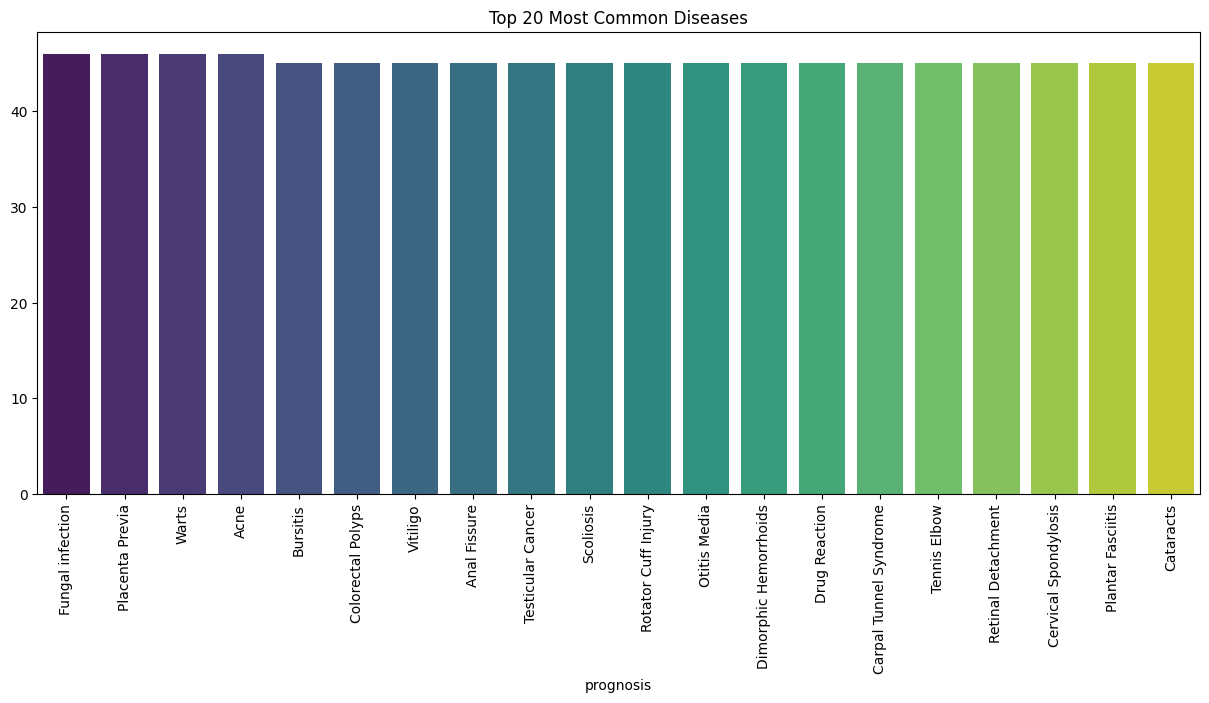

In [23]:
# Distribution of diseases
plt.figure(figsize=(15, 6))
disease_counts = df['prognosis'].value_counts()
sns.barplot(x=disease_counts.index[:20], y=disease_counts.values[:20], palette='viridis')
plt.xticks(rotation=90)
plt.title('Top 20 Most Common Diseases')
plt.show()


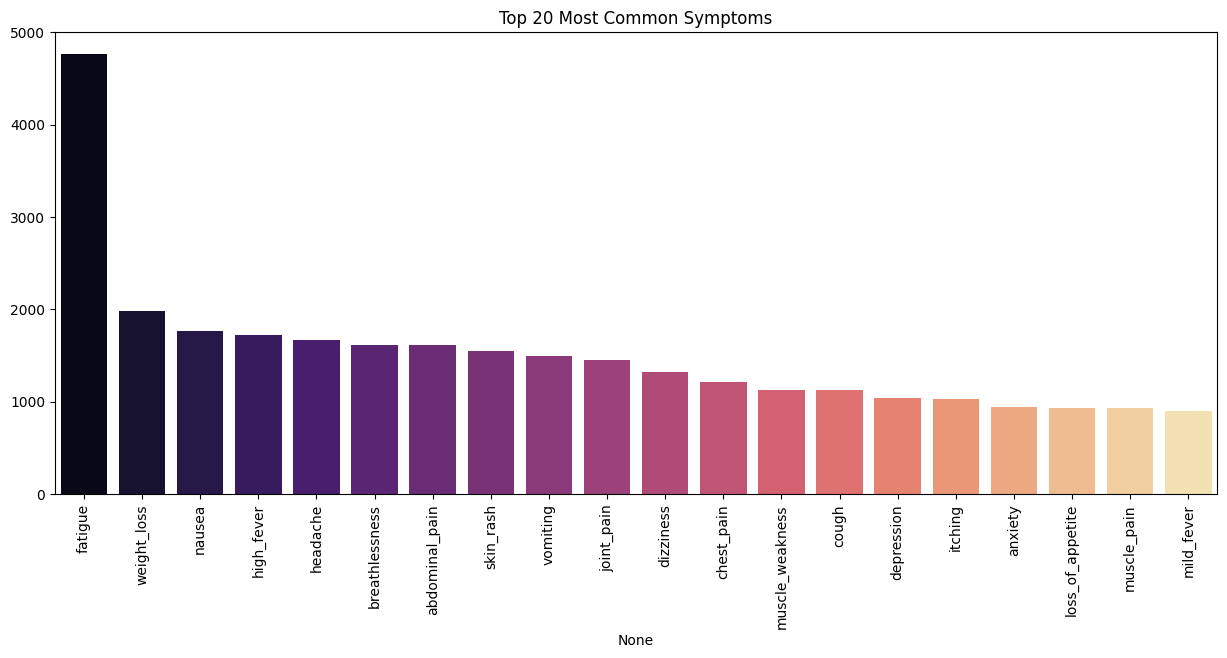

In [24]:
# Symptoms Frequency distribution
plt.figure(figsize=(15, 6))
symptom_sums = X.sum().sort_values(ascending=False)
sns.barplot(x=symptom_sums.index[:20], y=symptom_sums.values[:20], palette='magma')
plt.xticks(rotation=90)
plt.title('Top 20 Most Common Symptoms')
plt.show()


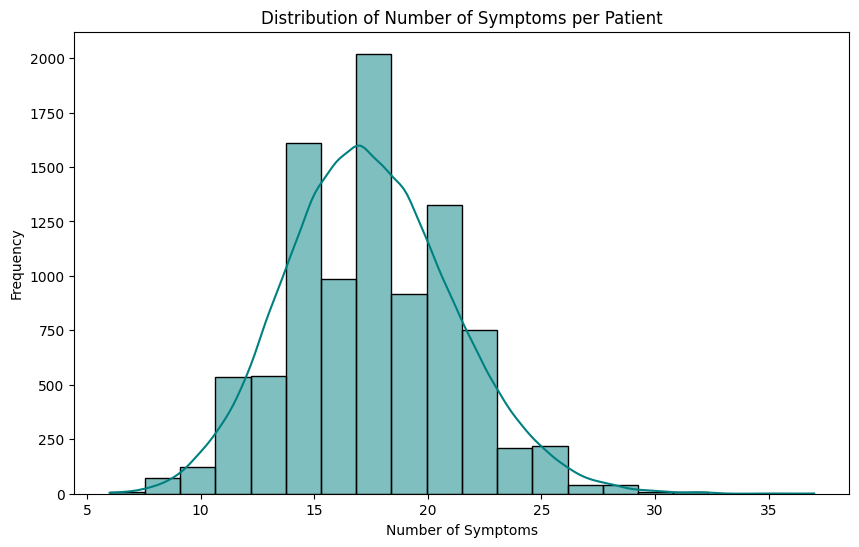

In [25]:
# Histogram: Number of Symptoms per Patient (Disease instance)
num_symptoms = X.sum(axis=1)
plt.figure(figsize=(10, 6))
sns.histplot(num_symptoms, bins=20, kde=True, color='teal')
plt.title('Distribution of Number of Symptoms per Patient')
plt.xlabel('Number of Symptoms')
plt.ylabel('Frequency')
plt.show()


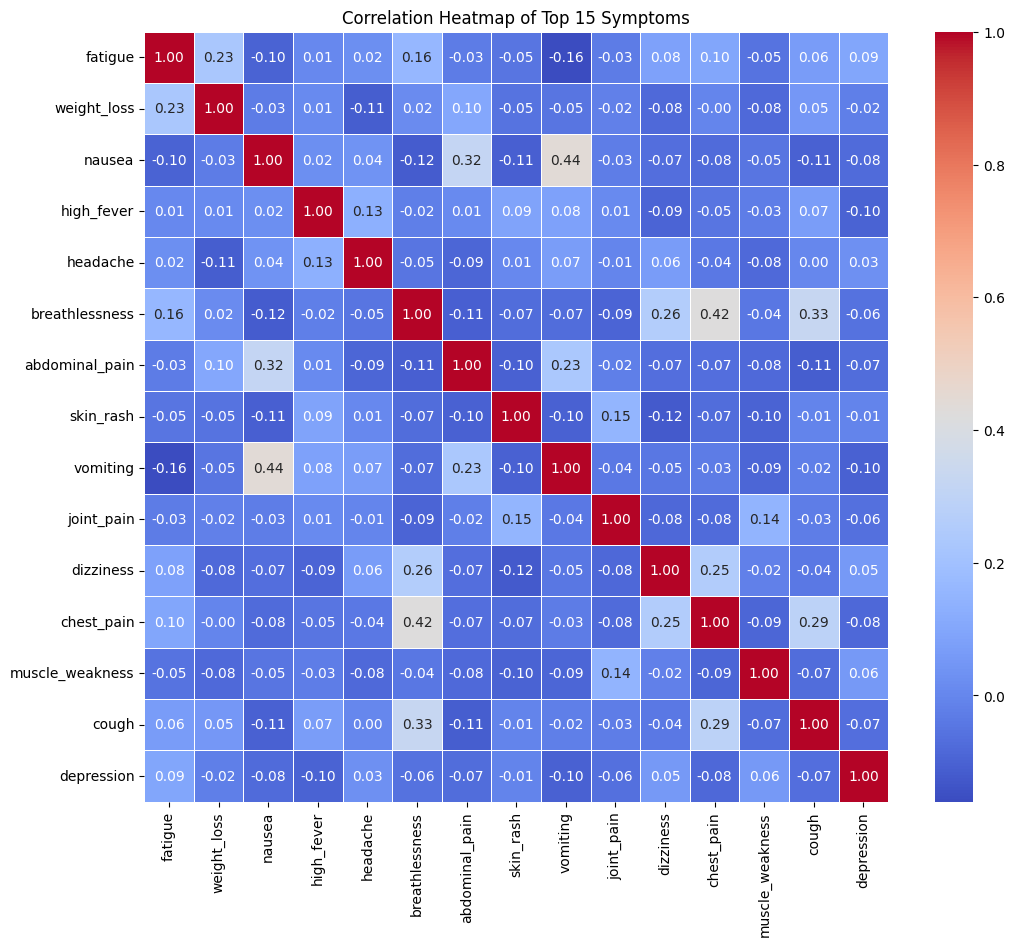

In [26]:
# Heatmap: Correlation between Top 15 Symptoms
top_symptoms = symptom_sums.index[:15]
X_top = X[top_symptoms]
corr_matrix = X_top.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Top 15 Symptoms')
plt.show()


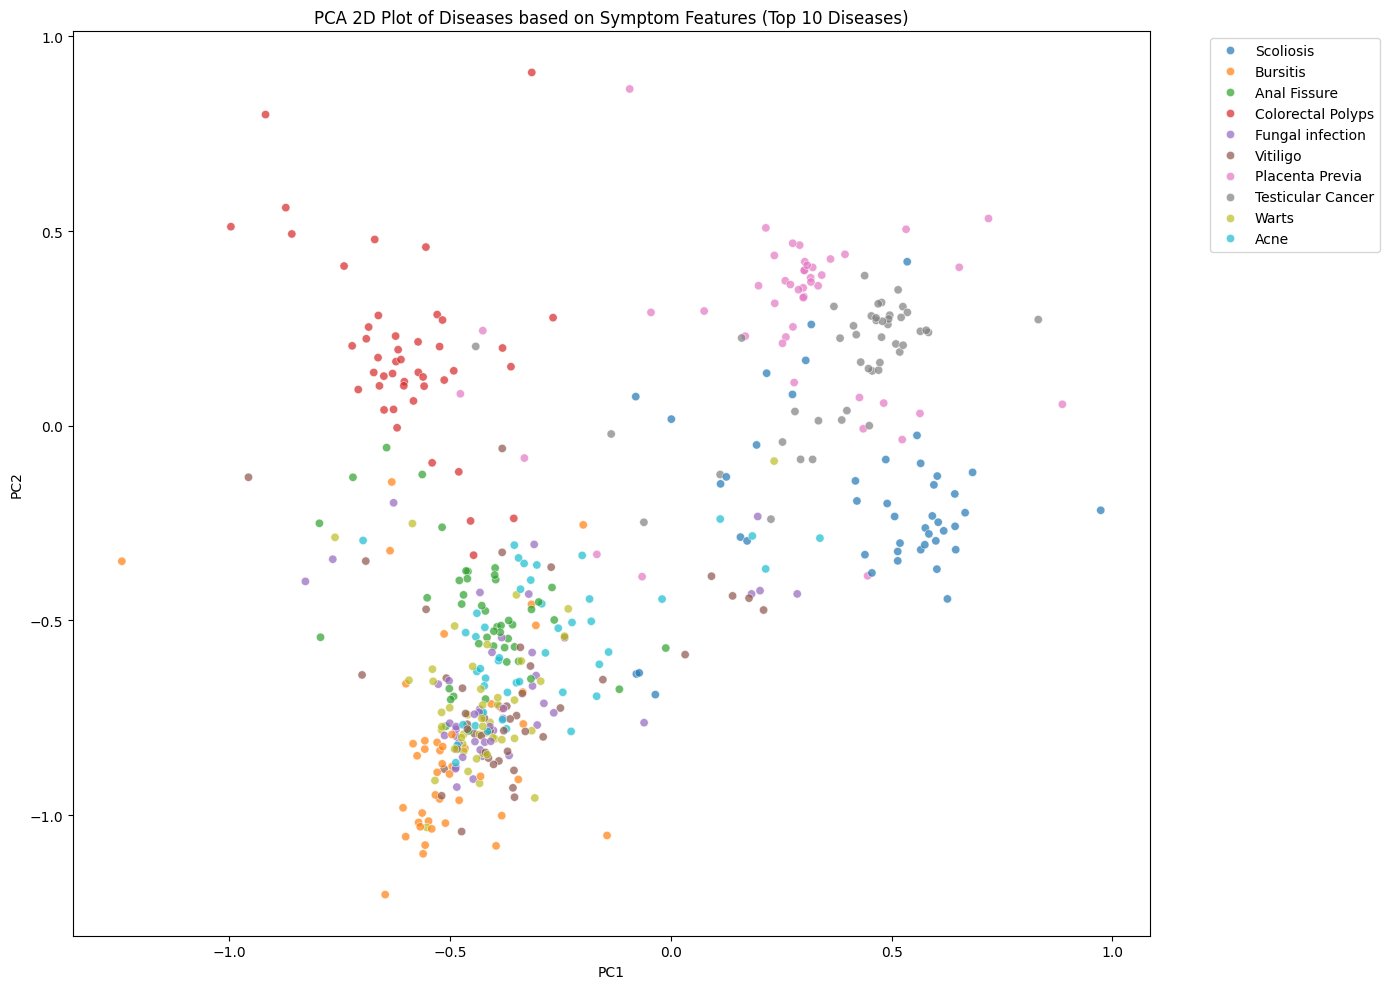

In [27]:
# PCA Dimensionality Reduction to visualize Clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Target'] = label_encoder.inverse_transform(y_encoded)

plt.figure(figsize=(14, 10))
# Only plotting top 10 diseases to avoid clutter
top_10_diseases = disease_counts.index[:10]
subset_pca_df = pca_df[pca_df['Target'].isin(top_10_diseases)]

sns.scatterplot(x='PC1', y='PC2', hue='Target', data=subset_pca_df, palette='tab10', alpha=0.7)
plt.title('PCA 2D Plot of Diseases based on Symptom Features (Top 10 Diseases)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 4. Machine Learning Implementation


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
model_accuracies = {}
predictions_dict = {} # Stored to calculate confusion matrix of best model later


In [29]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
preds = rf.predict(X_test)
model_accuracies['Random Forest'] = accuracy_score(y_test, preds)
predictions_dict['Random Forest'] = preds
print(f'Random Forest: {model_accuracies["Random Forest"]*100:.2f}%')


Random Forest: 94.32%


In [30]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
preds = dt.predict(X_test)
model_accuracies['Decision Tree'] = accuracy_score(y_test, preds)
predictions_dict['Decision Tree'] = preds
print(f'Decision Tree: {model_accuracies["Decision Tree"]*100:.2f}%')


Decision Tree: 53.64%


In [31]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
preds = lr.predict(X_test)
model_accuracies['Logistic Regression'] = accuracy_score(y_test, preds)
predictions_dict['Logistic Regression'] = preds
print(f'Logistic Regression: {model_accuracies["Logistic Regression"]*100:.2f}%')


Logistic Regression: 95.11%


In [32]:
nb = GaussianNB()
nb.fit(X_train, y_train)
preds = nb.predict(X_test)
model_accuracies['Naive Bayes'] = accuracy_score(y_test, preds)
predictions_dict['Naive Bayes'] = preds
print(f'Naive Bayes: {model_accuracies["Naive Bayes"]*100:.2f}%')


Naive Bayes: 5.26%


In [33]:
gb = GradientBoostingClassifier(n_estimators=50, random_state=42)
gb.fit(X_train, y_train)
preds = gb.predict(X_test)
model_accuracies['Gradient Boosting'] = accuracy_score(y_test, preds)
predictions_dict['Gradient Boosting'] = preds
print(f'Gradient Boosting: {model_accuracies["Gradient Boosting"]*100:.2f}%')


Gradient Boosting: 2.39%


In [34]:
svc = SVC(kernel='linear', random_state=42)
svc.fit(X_train, y_train)
preds = svc.predict(X_test)
model_accuracies['Support Vector Machine'] = accuracy_score(y_test, preds)
predictions_dict['Support Vector Machine'] = preds
print(f'SVC: {model_accuracies["Support Vector Machine"]*100:.2f}%')


SVC: 95.38%


In [35]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train, y_train)
preds = knn.predict(X_test)
model_accuracies['K-Nearest Neighbors'] = accuracy_score(y_test, preds)
predictions_dict['K-Nearest Neighbors'] = preds
print(f'KNN: {model_accuracies["K-Nearest Neighbors"]*100:.2f}%')


KNN: 83.54%


In [36]:
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
mlp.fit(X_train, y_train)
preds = mlp.predict(X_test)
model_accuracies['Neural Network (MLP)'] = accuracy_score(y_test, preds)
predictions_dict['Neural Network (MLP)'] = preds
print(f'MLP Neural Network: {model_accuracies["Neural Network (MLP)"]*100:.2f}%')


MLP Neural Network: 92.30%


## 5. Model Accuracy Comparison


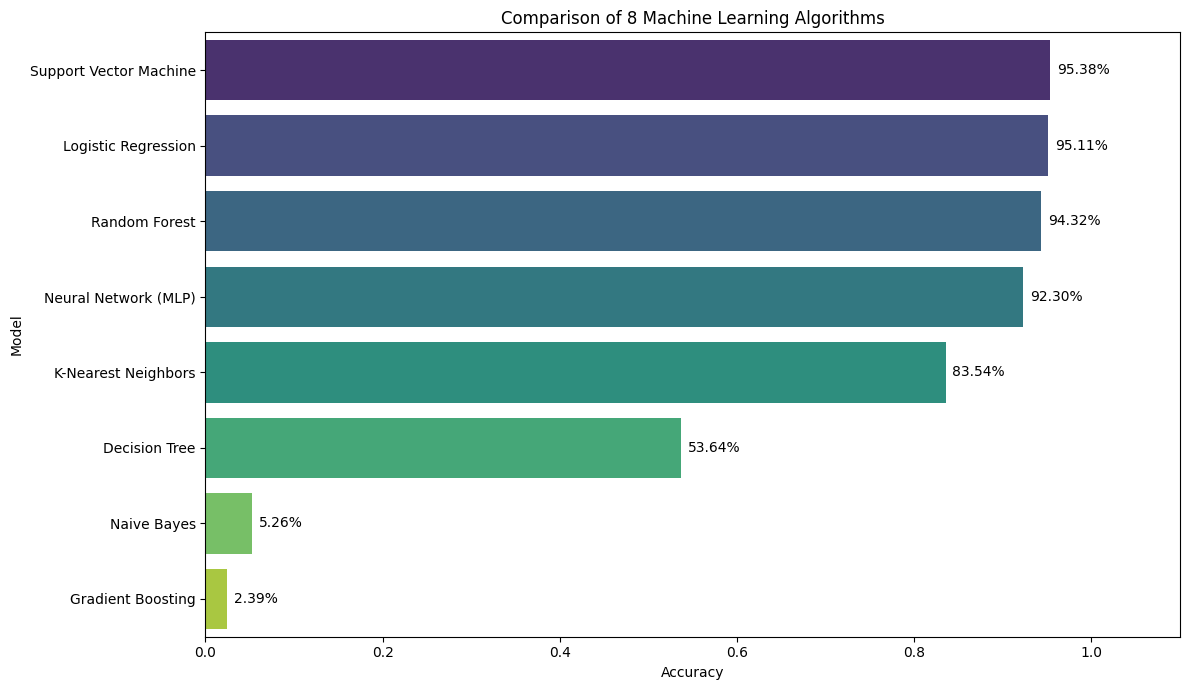

In [37]:
acc_df = pd.DataFrame(list(model_accuracies.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Accuracy', y='Model', data=acc_df, palette='viridis')
plt.xlim(0, 1.1)
plt.title('Comparison of 8 Machine Learning Algorithms')
plt.xlabel('Accuracy')

for p in ax.patches:
    ax.annotate(f'{p.get_width()*100:.2f}%', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', xytext=(5, 0), 
                textcoords='offset points')
plt.tight_layout()
plt.show()


## 6. Confusion Matrix for Top Model


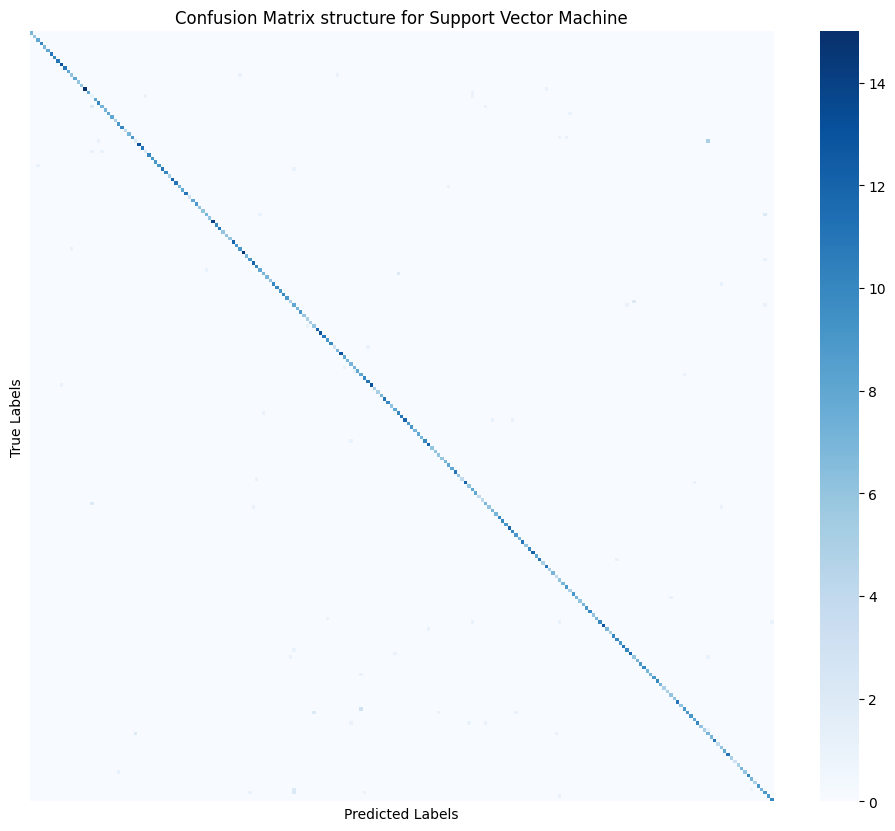

In [38]:
best_model_name = acc_df.iloc[0]['Model']
best_preds = predictions_dict[best_model_name]

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap='Blues', xticklabels=False, yticklabels=False)
plt.title(f'Confusion Matrix structure for {best_model_name}')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


## 7. Interactive Disease Prediction Engine
Provide a list of symptoms below, and the highest-accuracy model will output the predicted disease!


In [39]:
# Let's use the Random Forest model (or whichever scored best) to predict a custom patient's symptoms
def predict_disease_from_symptoms(symptoms_list, model, encoder, feature_names):
    # Create a zero-filled vector for all dataset features
    input_vector = np.zeros(len(feature_names))
    
    # For every symptom the user typed, if it exists in the features, set that index to 1
    for symptom in symptoms_list:
        formatted_symptom = symptom.replace(' ', '_').lower() # normalize string format
        if formatted_symptom in feature_names:
            index = list(feature_names).index(formatted_symptom)
            input_vector[index] = 1
        else:
            print(f"Warning: Symptom '{symptom}' not recognized in dataset vocabulary.")
            
    # Make prediction
    prediction = model.predict([input_vector])
    disease = encoder.inverse_transform(prediction)[0]
    return disease

# ----------------------------------------------------------------
# 💉 ENTER YOUR CUSTOM SYMPTOMS HERE:
# Example symptoms: itching, skin rash, nodal skin eruptions, shivering, chills, joint pain
# ----------------------------------------------------------------
my_symptoms = [
    'itching', 
    'skin rash', 
    'shivering'
]

# Using the Random Forest model (rf_model) trained earlier in Step 4
predicted_disease = predict_disease_from_symptoms(my_symptoms, rf, label_encoder, X.columns)
print('\n' + '='*50)
print(f'🏥 PATIENT SYMPTOMS: {my_symptoms}')
print(f'🩺 AI PREDICTED DISEASE: >> {predicted_disease} <<')
print('='*50)



🏥 PATIENT SYMPTOMS: ['itching', 'skin rash', 'shivering']
🩺 AI PREDICTED DISEASE: >> Fungal infection <<
